# RSO-80: Assess the Scheduler CSC configuration time after enabling

**Descripcion**

I was interested in evaluating the time from when the scheduler CSC is enabled, to when the scheduler CSC is configured.

 

The context for this is to evaluate the overall latency of the Rubin ToO system. We have advanced information from the LVK side, and 2/5 of the Rubin steps for observing. 

 

My thought would be to evaluate this over the entire commissioning period, OR over a period of time since we have deployed any improvements to minimize the configure time.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsEndTime,
    getDayObsForTime,
    getDayObsStartTime,
    makeEfdClient,
)
from astropy.time import Time

In [2]:
# Initialize an EFD client
efd_client = makeEfdClient()

In [3]:
# day_obs = 20250601
start_time = Time("2026-01-10T00:00:00Z", scale="utc")
end_time = Time("2026-01-15T23:30:00Z", scale="utc")

## ************************

In [4]:
# Disable
df_disable = getEfdData(
             client=efd_client,
             topic="lsst.sal.Scheduler.command_disable",
             columns=["*"],
             begin=start_time,
             end=end_time,
)

In [5]:
df_disable['timestamp'] = df_disable.index
df_disable

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:21:51.755275+00:00,1.768008e+09,Script:111453,1.768008e+09,3400085,0,9c0ea436,326174075,1.768008e+09,1,2026-01-10 01:21:51.755275+00:00
2026-01-10 23:51:10.728102+00:00,1.768089e+09,Script:213822,1.768089e+09,3988392,0,9c0ea436,326174075,1.768089e+09,2,2026-01-10 23:51:10.728102+00:00
2026-01-11 00:32:34.236172+00:00,1.768092e+09,Script:112073,1.768092e+09,3946145,0,9c0ea436,326174075,1.768092e+09,1,2026-01-11 00:32:34.236172+00:00
2026-01-11 01:36:26.601585+00:00,1.768095e+09,Script:213884,1.768095e+09,4023197,0,9c0ea436,326174075,1.768095e+09,2,2026-01-11 01:36:26.601585+00:00
2026-01-11 14:09:01.513233+00:00,1.768141e+09,Script:214385,1.768141e+09,141507,0,9c0ea436,326174075,1.768141e+09,2,2026-01-11 14:09:01.513233+00:00
2026-01-12 00:07:05.932101+00:00,1.768176e+09,Script:214416,1.768176e+09,150391,0,9c0ea436,326174075,1.768176e+09,2,2026-01-12 00:07:05.932101+00:00
2026-01-12 07:03:19.758704+00:00,1.768201e+09,Script:112758,1.768201e+09,376781,0,9c0ea436,326174075,1.768201e+09,1,2026-01-12 07:03:19.758704+00:00
2026-01-12 23:51:16.872159+00:00,1.768262e+09,Script:215018,1.768262e+09,504670,0,9c0ea436,326174075,1.768262e+09,2,2026-01-12 23:51:16.872159+00:00
2026-01-13 04:39:10.763242+00:00,1.768279e+09,Script:112987,1.768279e+09,535953,0,9c0ea436,326174075,1.768279e+09,1,2026-01-13 04:39:10.763242+00:00
2026-01-13 23:51:24.910814+00:00,1.768348e+09,Script:215427,1.768348e+09,744080,0,9c0ea436,326174075,1.768348e+09,2,2026-01-13 23:51:24.910814+00:00


In [6]:
# Enable
df_enable = getEfdData(
            client=efd_client,
            topic="lsst.sal.Scheduler.command_enable",
            columns=["*"],
            begin=start_time,
            end=end_time,
)

In [7]:
df_enable['timestamp'] = df_enable.index
df_enable

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:27:23.198661+00:00,1.768008e+09,Script:111453,1.768008e+09,3400085,0,4123e633,476961495,1.768008e+09,1,2026-01-10 01:27:23.198661+00:00
2026-01-10 23:51:45.790239+00:00,1.768089e+09,Script:213822,1.768089e+09,3988392,0,4123e633,476961495,1.768089e+09,2,2026-01-10 23:51:45.790239+00:00
2026-01-11 00:37:43.405530+00:00,1.768092e+09,Script:112073,1.768092e+09,3946145,0,4123e633,476961495,1.768092e+09,1,2026-01-11 00:37:43.405530+00:00
2026-01-11 01:37:04.950707+00:00,1.768095e+09,Script:213884,1.768095e+09,4023197,0,4123e633,476961495,1.768095e+09,2,2026-01-11 01:37:04.950707+00:00
2026-01-11 14:09:38.495453+00:00,1.768141e+09,Script:214385,1.768141e+09,141507,0,4123e633,476961495,1.768141e+09,2,2026-01-11 14:09:38.495453+00:00
2026-01-12 00:07:57.981250+00:00,1.768176e+09,Script:214416,1.768177e+09,150391,0,4123e633,476961495,1.768177e+09,2,2026-01-12 00:07:57.981250+00:00
2026-01-12 07:09:15.012064+00:00,1.768202e+09,Script:112758,1.768202e+09,376781,0,4123e633,476961495,1.768202e+09,1,2026-01-12 07:09:15.012064+00:00
2026-01-12 23:51:54.150495+00:00,1.768262e+09,Script:215018,1.768262e+09,504670,0,4123e633,476961495,1.768262e+09,2,2026-01-12 23:51:54.150495+00:00
2026-01-13 04:44:51.623314+00:00,1.768279e+09,Script:112987,1.768280e+09,535953,0,4123e633,476961495,1.768280e+09,1,2026-01-13 04:44:51.623314+00:00
2026-01-13 23:52:00.632737+00:00,1.768348e+09,Script:215427,1.768348e+09,744080,0,4123e633,476961495,1.768348e+09,2,2026-01-13 23:52:00.632737+00:00


In [8]:
# Exit Control
df_exitControl = getEfdData(
                 client=efd_client,
                 topic="lsst.sal.Scheduler.command_exitControl",
                 columns=["*"],
                 begin=start_time,
                 end=end_time,
)

In [9]:
df_exitControl['timestamp'] = df_exitControl.index
df_exitControl

,timestamp


In [10]:
# setLogLevel
df_setLogLevel = getEfdData(
                 client=efd_client,
                 topic="lsst.sal.Scheduler.command_setLogLevel",
                 columns=["*"],
                 begin=start_time,
                 end=end_time,
)

In [11]:
df_setLogLevel['timestamp'] = df_setLogLevel.index
df_setLogLevel

,timestamp


In [12]:
# standby
df_standby = getEfdData(
             client=efd_client,
             topic="lsst.sal.Scheduler.command_standby",
             columns=["*"],
             begin=start_time,
             end=end_time,
)

In [13]:
df_standby['timestamp'] = df_standby.index
df_standby

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:21:57.334168+00:00,1.768008e+09,Script:111453,1.768008e+09,3400085,0,cd1b64f4,1616103400,1.768008e+09,1,2026-01-10 01:21:57.334168+00:00
2026-01-10 23:51:16.307530+00:00,1.768089e+09,Script:213822,1.768089e+09,3988392,0,cd1b64f4,1616103400,1.768089e+09,2,2026-01-10 23:51:16.307530+00:00
2026-01-11 00:32:39.820630+00:00,1.768092e+09,Script:112073,1.768092e+09,3946145,0,cd1b64f4,1616103400,1.768092e+09,1,2026-01-11 00:32:39.820630+00:00
2026-01-11 01:36:32.176299+00:00,1.768095e+09,Script:213884,1.768095e+09,4023197,0,cd1b64f4,1616103400,1.768095e+09,2,2026-01-11 01:36:32.176299+00:00
2026-01-11 14:09:07.086490+00:00,1.768141e+09,Script:214385,1.768141e+09,141507,0,cd1b64f4,1616103400,1.768141e+09,2,2026-01-11 14:09:07.086490+00:00
2026-01-12 00:07:11.494748+00:00,1.768176e+09,Script:214416,1.768176e+09,150391,0,cd1b64f4,1616103400,1.768176e+09,2,2026-01-12 00:07:11.494748+00:00
2026-01-12 07:03:25.306961+00:00,1.768201e+09,Script:112758,1.768201e+09,376781,0,cd1b64f4,1616103400,1.768201e+09,1,2026-01-12 07:03:25.306961+00:00
2026-01-12 23:51:22.475054+00:00,1.768262e+09,Script:215018,1.768262e+09,504670,0,cd1b64f4,1616103400,1.768262e+09,2,2026-01-12 23:51:22.475054+00:00
2026-01-13 04:39:16.316808+00:00,1.768279e+09,Script:112987,1.768279e+09,535953,0,cd1b64f4,1616103400,1.768279e+09,1,2026-01-13 04:39:16.316808+00:00
2026-01-13 23:51:30.485094+00:00,1.768348e+09,Script:215427,1.768348e+09,744080,0,cd1b64f4,1616103400,1.768348e+09,2,2026-01-13 23:51:30.485094+00:00


In [14]:
# Start
df_start = getEfdData(
           client=efd_client,
           topic="lsst.sal.Scheduler.command_start",
           columns=["*"],
           begin=start_time,
           end=end_time,
)

In [15]:
df_start['timestamp'] = df_start.index
df_start

,configurationOverride,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:21:58.386950+00:00,fbs_config_lsst_survey_block_419.yaml,1.768008e+09,Script:111453,1.768008e+09,3400085,0,52da5621,1851544648,1.768008e+09,1,2026-01-10 01:21:58.386950+00:00
2026-01-10 23:51:17.371641+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768089e+09,Script:213822,1.768089e+09,3988392,0,52da5621,1851544648,1.768089e+09,2,2026-01-10 23:51:17.371641+00:00
2026-01-11 00:32:40.893540+00:00,fbs_config_lsst_survey_block_419.yaml,1.768092e+09,Script:112073,1.768092e+09,3946145,0,52da5621,1851544648,1.768092e+09,1,2026-01-11 00:32:40.893540+00:00
2026-01-11 01:36:33.243459+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768095e+09,Script:213884,1.768095e+09,4023197,0,52da5621,1851544648,1.768095e+09,2,2026-01-11 01:36:33.243459+00:00
2026-01-11 14:09:08.158330+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768141e+09,Script:214385,1.768141e+09,141507,0,52da5621,1851544648,1.768141e+09,2,2026-01-11 14:09:08.158330+00:00
2026-01-12 00:07:12.551209+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768176e+09,Script:214416,1.768176e+09,150391,0,52da5621,1851544648,1.768176e+09,2,2026-01-12 00:07:12.551209+00:00
2026-01-12 07:03:26.375660+00:00,fbs_config_lsst_survey_block_419.yaml,1.768201e+09,Script:112758,1.768201e+09,376781,0,52da5621,1851544648,1.768201e+09,1,2026-01-12 07:03:26.375660+00:00
2026-01-12 23:51:23.522967+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768262e+09,Script:215018,1.768262e+09,504670,0,52da5621,1851544648,1.768262e+09,2,2026-01-12 23:51:23.522967+00:00
2026-01-13 04:39:17.389900+00:00,fbs_config_lsst_survey_block_419.yaml,1.768279e+09,Script:112987,1.768279e+09,535953,0,52da5621,1851544648,1.768279e+09,1,2026-01-13 04:39:17.389900+00:00
2026-01-13 23:51:31.544646+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768348e+09,Script:215427,1.768348e+09,744080,0,52da5621,1851544648,1.768348e+09,2,2026-01-13 23:51:31.544646+00:00


## latencies

In [16]:
for df in [df_disable, df_enable, df_standby, df_start]:
    df['script_id'] = df['private_identity'].str.replace('Script:', '', regex=False).astype(int)

In [17]:
df_disable_lat = df_disable[['script_id', 'timestamp']]
df_enable_lat  = df_enable[['script_id', 'timestamp']]
df_standby_lat = df_standby[['script_id', 'timestamp']]
df_start_lat    = df_start[['script_id', 'timestamp']]

In [18]:
# Rename column of timestamp
df_disable_lat = df_disable_lat.rename(columns={'timestamp': 'ts_disable'})
df_enable_lat  = df_enable_lat.rename(columns={'timestamp': 'ts_enable'})
df_standby_lat = df_standby_lat.rename(columns={'timestamp': 'ts_standby'})
df_start_lat    = df_start_lat.rename(columns={'timestamp': 'ts_start'})

In [19]:
# Partial Latencies 
df_latencies = (
    df_disable_lat
    .merge(df_enable_lat,  on='script_id', how='inner')
    .merge(df_standby_lat, on='script_id', how='inner')
    .merge(df_start_lat,   on='script_id', how='inner')
)

In [20]:
df_latencies['lat_disable_enable_s'] = (
    df_latencies['ts_enable'] - df_latencies['ts_disable']
).dt.total_seconds() # * 1000

In [21]:
df_latencies['lat_enable_standby_s'] = (
    df_latencies['ts_standby'] - df_latencies['ts_enable']
).dt.total_seconds() # * 1000

In [22]:
df_latencies['lat_standby_start_s'] = (
    df_latencies['ts_start'] - df_latencies['ts_standby']
).dt.total_seconds()

In [23]:
df_latencies['lat_total_s'] = (
    df_latencies['ts_start'] - df_latencies['ts_disable']
).dt.total_seconds() # * 1000

In [24]:
df_latencies

,script_id,ts_disable,ts_enable,ts_standby,ts_start,lat_disable_enable_s,lat_enable_standby_s,lat_standby_start_s,lat_total_s
0,111453,2026-01-10 01:21:51.755275+00:00,2026-01-10 01:27:23.198661+00:00,2026-01-10 01:21:57.334168+00:00,2026-01-10 01:21:58.386950+00:00,331.443386,-325.864493,1.052782,6.631675
1,213822,2026-01-10 23:51:10.728102+00:00,2026-01-10 23:51:45.790239+00:00,2026-01-10 23:51:16.307530+00:00,2026-01-10 23:51:17.371641+00:00,35.062137,-29.482709,1.064111,6.643539
2,112073,2026-01-11 00:32:34.236172+00:00,2026-01-11 00:37:43.405530+00:00,2026-01-11 00:32:39.820630+00:00,2026-01-11 00:32:40.893540+00:00,309.169358,-303.584900,1.072910,6.657368
3,213884,2026-01-11 01:36:26.601585+00:00,2026-01-11 01:37:04.950707+00:00,2026-01-11 01:36:32.176299+00:00,2026-01-11 01:36:33.243459+00:00,38.349122,-32.774408,1.067160,6.641874
4,214385,2026-01-11 14:09:01.513233+00:00,2026-01-11 14:09:38.495453+00:00,2026-01-11 14:09:07.086490+00:00,2026-01-11 14:09:08.158330+00:00,36.982220,-31.408963,1.071840,6.645097
5,214416,2026-01-12 00:07:05.932101+00:00,2026-01-12 00:07:57.981250+00:00,2026-01-12 00:07:11.494748+00:00,2026-01-12 00:07:12.551209+00:00,52.049149,-46.486502,1.056461,6.619108
6,112758,2026-01-12 07:03:19.758704+00:00,2026-01-12 07:09:15.012064+00:00,2026-01-12 07:03:25.306961+00:00,2026-01-12 07:03:26.375660+00:00,355.253360,-349.705103,1.068699,6.616956
7,215018,2026-01-12 23:51:16.872159+00:00,2026-01-12 23:51:54.150495+00:00,2026-01-12 23:51:22.475054+00:00,2026-01-12 23:51:23.522967+00:00,37.278336,-31.675441,1.047913,6.650808
8,112987,2026-01-13 04:39:10.763242+00:00,2026-01-13 04:44:51.623314+00:00,2026-01-13 04:39:16.316808+00:00,2026-01-13 04:39:17.389900+00:00,340.860072,-335.306506,1.073092,6.626658
9,215427,2026-01-13 23:51:24.910814+00:00,2026-01-13 23:52:00.632737+00:00,2026-01-13 23:51:30.485094+00:00,2026-01-13 23:51:31.544646+00:00,35.721923,-30.147643,1.059552,6.633832


### Plots

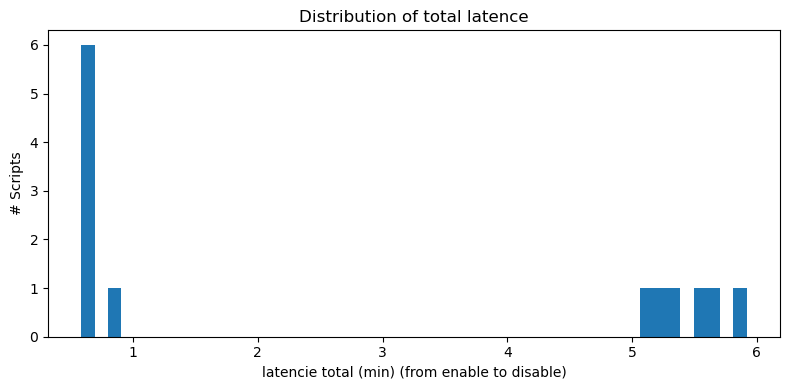

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(df_latencies['lat_disable_enable_s'] / 60.0, bins=50)
plt.xlabel('latencie total (min) (from enable to disable)')
plt.ylabel('# Scripts')
plt.title('Distribution of total latence')
plt.tight_layout()
plt.show()

In [26]:
df_latencies['lat_disable_enable_s'].describe(percentiles=[0.5, 0.95, 0.99])


count     13.000000
mean     172.766872
std      150.761526
min       35.062137
50%       52.049149
95%      346.617387
99%      353.526165
max      355.253360
Name: lat_disable_enable_s, dtype: float64

In [27]:
# We group by observation night
df_latencies['date'] = df_latencies['ts_enable'].dt.date

mean_by_night = df_latencies.groupby('date')['lat_disable_enable_s'].mean().reset_index()
print(mean_by_night)


         date  lat_disable_enable_s
0  2026-01-10            183.252761
1  2026-01-11            128.166900
2  2026-01-12            148.193615
3  2026-01-13            188.290998
4  2026-01-14            176.581035
5  2026-01-15            320.638198


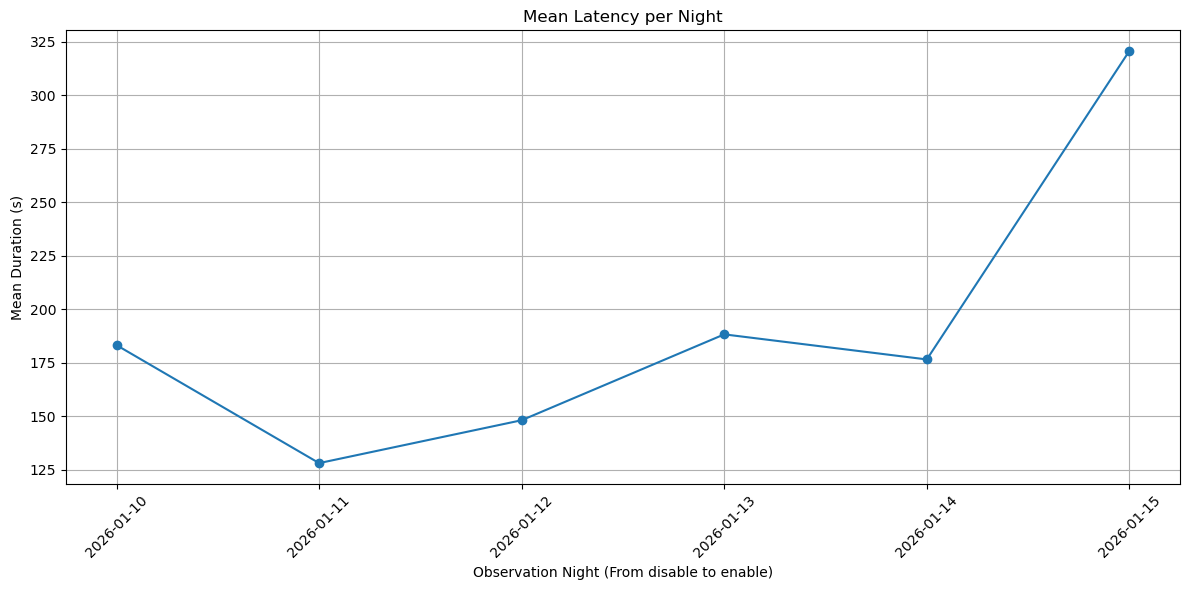

In [28]:
mean_by_night['date'] = pd.to_datetime(mean_by_night['date'])

plt.figure(figsize=(12,6))
plt.plot(mean_by_night['date'], mean_by_night['lat_disable_enable_s'], marker='o')
plt.xlabel('Observation Night (From disable to enable)')
plt.ylabel('Mean Duration (s)')
plt.title('Mean Latency per Night')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9802/190149007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


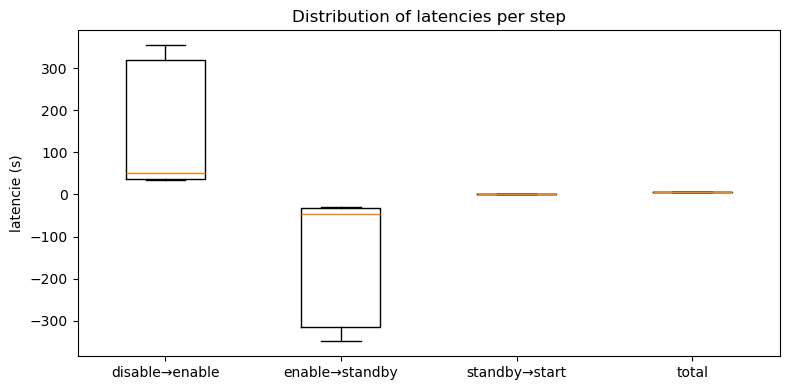

In [29]:
plt.figure(figsize=(8, 4))

plt.boxplot([
    df_latencies['lat_disable_enable_s'],
    df_latencies['lat_enable_standby_s'],
    df_latencies['lat_standby_start_s'],
    df_latencies['lat_total_s'],
], labels=[
    'disable→enable',
    'enable→standby',
    'standby→start',
    'total'
])

plt.ylabel('latencie (s)')
plt.title('Distribution of latencies per step')
plt.tight_layout()
plt.show()

From Enable to standby doesn't make sense

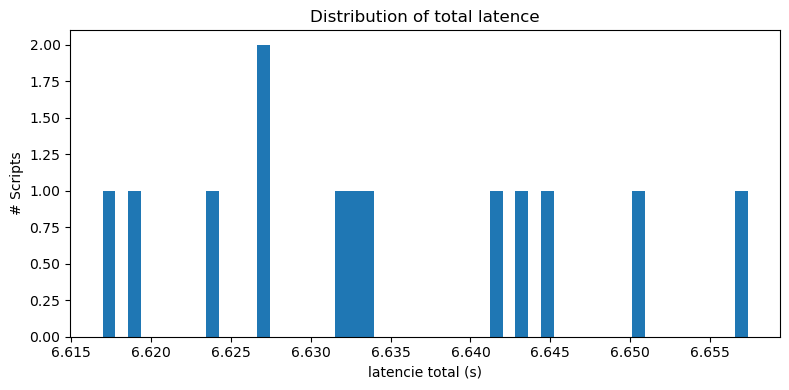

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(df_latencies['lat_total_s'], bins=50)
plt.xlabel('latencie total (s)')
plt.ylabel('# Scripts')
plt.title('Distribution of total latence')
plt.tight_layout()
plt.show()

# MTCamara

In [31]:
# MTCamare observational times
df_mtcamara = getEfdData(
            client=efd_client,
            topic="lsst.sal.MTCamera.logevent_endOfImageTelemetry",
            columns=["*"],
            begin=start_time,
            end=end_time,
)

In [32]:
df_mtcamara['timestamp'] = df_mtcamara.index
df_mtcamara['tsDateObs'] = df_mtcamara.index
df_mtcamara

,additionalKeys,additionalValues,darkTime,emulatedImage,exposureTime,imageController,imageDate,imageIndex,imageName,imageNumber,...,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,timestampAcquisitionStart,timestampDateEnd,timestampDateObs,timestamp,tsDateObs
2026-01-10 01:29:06.402368+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-10T01\:28\:43.605#1:ACQ:0:0:0.0:IN...,30.934112,,30,O,20260109,1,MC_O_20260109_000004,4,...,1107748365,0,c056116d,144577,1.768009e+09,1.768009e+09,1.768009e+09,1.768009e+09,2026-01-10 01:29:06.402368+00:00,2026-01-10 01:29:06.402368+00:00
2026-01-10 01:29:40.811844+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-10T01\:28\:43.605:ACQ:0:0:0.0:INFO...,30.930641,,30,O,20260109,1,MC_O_20260109_000005,5,...,1107748365,0,c056116d,144984,1.768009e+09,1.768009e+09,1.768009e+09,1.768009e+09,2026-01-10 01:29:40.811844+00:00,2026-01-10 01:29:40.811844+00:00
2026-01-10 01:31:16.891504+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-10T01\:28\:43.605#2:ACQ:0:0:0.0:IN...,30.929627,,30,O,20260109,1,MC_O_20260109_000006,6,...,1107748365,0,c056116d,146258,1.768009e+09,1.768009e+09,1.768009e+09,1.768009e+09,2026-01-10 01:31:16.891504+00:00,2026-01-10 01:31:16.891504+00:00
2026-01-10 01:31:51.260259+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-10T01\:28\:43.605:ACQ:0:0:0.0:INFO...,30.934454,,30,O,20260109,1,MC_O_20260109_000007,7,...,1107748365,0,c056116d,146685,1.768009e+09,1.768009e+09,1.768009e+09,1.768009e+09,2026-01-10 01:31:51.260259+00:00,2026-01-10 01:31:51.260259+00:00
2026-01-10 01:33:11.814532+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-10T01\:28\:44.621#1:ACQ:0:0:0.0:IN...,30.931430,,30,O,20260109,1,MC_O_20260109_000008,8,...,1107748365,0,c056116d,147714,1.768009e+09,1.768009e+09,1.768009e+09,1.768009e+09,2026-01-10 01:33:11.814532+00:00,2026-01-10 01:33:11.814532+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-15 21:40:36.082825+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2026-01-15T21\:41\:03.694:DARK:0:0:0.0:LS...,5.015375,,5,O,20260115,1,MC_O_20260115_000001,1,...,2026153373,0,c056116d,61542,1.768513e+09,1.768513e+09,1.768513e+09,1.768513e+09,2026-01-15 21:40:36.082825+00:00,2026-01-15 21:40:36.082825+00:00
2026-01-15 21:40:44.307468+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2026-01-15T21\:41\:03.694:DARK:0:0:0.0:LS...,5.014607,,5,O,20260115,1,MC_O_20260115_000002,2,...,2026153373,0,c056116d,61656,1.768513e+09,1.768513e+09,1.768513e+09,1.768513e+09,2026-01-15 21:40:44.307468+00:00,2026-01-15 21:40:44.307468+00:00
2026-01-15 21:40:52.953145+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2026-01-15T21\:41\:03.694:DARK:0:0:0.0:LS...,5.015374,,5,O,20260115,1,MC_O_20260115_000003,3,...,2026153373,0,c056116d,61769,1.768513e+09,1.768513e+09,1.768513e+09,1.768513e+09,2026-01-15 21:40:52.953145+00:00,2026-01-15 21:40:52.953145+00:00
2026-01-15 21:41:01.334152+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2026-01-15T21\:41\:03.694:DARK:0:0:0.0:LS...,5.012674,,5,O,20260115,1,MC_O_20260115_000004,4,...,2026153373,0,c056116d,61922,1.768513e+09,1.768513e+09,1.768513e+09,1.768513e+09,2026-01-15 21:41:01.334152+00:00,2026-01-15 21:41:01.334152+00:00


For each script execution, the latency between the time the script was enabled (`ts_enable`) and the next camera data acquisition (`tsDataObs`) that occurred after that enable time.

For every row in `df_latencies`, we search in `df_mtcamara` for the closest `tsDataObs` strictly greater than ts_enable.


In [33]:
# Sort both DataFrames by time
df_mtcamara = df_mtcamara.sort_values("tsDateObs").reset_index(drop=True)

In [34]:
df_latencies = pd.merge_asof(
    df_latencies,
    df_mtcamara['tsDateObs'],
    left_on="ts_enable",
    right_on="tsDateObs",
    direction="forward",   # ensures tsDataObs > ts_enable
    allow_exact_matches=False
)

In [35]:
#Compute the latency in seconds:
df_latencies["latency_camara"] = (
    df_latencies['tsDateObs'] - df_latencies['ts_enable']
).dt.total_seconds()

In [36]:
df_latencies

,script_id,ts_disable,ts_enable,ts_standby,ts_start,lat_disable_enable_s,lat_enable_standby_s,lat_standby_start_s,lat_total_s,date,tsDateObs,latency_camara
0,111453,2026-01-10 01:21:51.755275+00:00,2026-01-10 01:27:23.198661+00:00,2026-01-10 01:21:57.334168+00:00,2026-01-10 01:21:58.386950+00:00,331.443386,-325.864493,1.052782,6.631675,2026-01-10,2026-01-10 01:29:06.402368+00:00,103.203707
1,213822,2026-01-10 23:51:10.728102+00:00,2026-01-10 23:51:45.790239+00:00,2026-01-10 23:51:16.307530+00:00,2026-01-10 23:51:17.371641+00:00,35.062137,-29.482709,1.064111,6.643539,2026-01-10,2026-01-11 00:39:55.847422+00:00,2890.057183
2,112073,2026-01-11 00:32:34.236172+00:00,2026-01-11 00:37:43.405530+00:00,2026-01-11 00:32:39.820630+00:00,2026-01-11 00:32:40.893540+00:00,309.169358,-303.584900,1.072910,6.657368,2026-01-11,2026-01-11 00:39:55.847422+00:00,132.441892
3,213884,2026-01-11 01:36:26.601585+00:00,2026-01-11 01:37:04.950707+00:00,2026-01-11 01:36:32.176299+00:00,2026-01-11 01:36:33.243459+00:00,38.349122,-32.774408,1.067160,6.641874,2026-01-11,2026-01-11 01:37:53.034927+00:00,48.084220
4,214385,2026-01-11 14:09:01.513233+00:00,2026-01-11 14:09:38.495453+00:00,2026-01-11 14:09:07.086490+00:00,2026-01-11 14:09:08.158330+00:00,36.982220,-31.408963,1.071840,6.645097,2026-01-11,2026-01-11 15:19:33.737686+00:00,4195.242233
5,214416,2026-01-12 00:07:05.932101+00:00,2026-01-12 00:07:57.981250+00:00,2026-01-12 00:07:11.494748+00:00,2026-01-12 00:07:12.551209+00:00,52.049149,-46.486502,1.056461,6.619108,2026-01-12,2026-01-12 07:12:02.153457+00:00,25444.172207
6,112758,2026-01-12 07:03:19.758704+00:00,2026-01-12 07:09:15.012064+00:00,2026-01-12 07:03:25.306961+00:00,2026-01-12 07:03:26.375660+00:00,355.253360,-349.705103,1.068699,6.616956,2026-01-12,2026-01-12 07:12:02.153457+00:00,167.141393
7,215018,2026-01-12 23:51:16.872159+00:00,2026-01-12 23:51:54.150495+00:00,2026-01-12 23:51:22.475054+00:00,2026-01-12 23:51:23.522967+00:00,37.278336,-31.675441,1.047913,6.650808,2026-01-12,2026-01-13 00:35:05.662072+00:00,2591.511577
8,112987,2026-01-13 04:39:10.763242+00:00,2026-01-13 04:44:51.623314+00:00,2026-01-13 04:39:16.316808+00:00,2026-01-13 04:39:17.389900+00:00,340.860072,-335.306506,1.073092,6.626658,2026-01-13,2026-01-13 04:50:42.395625+00:00,350.772311
9,215427,2026-01-13 23:51:24.910814+00:00,2026-01-13 23:52:00.632737+00:00,2026-01-13 23:51:30.485094+00:00,2026-01-13 23:51:31.544646+00:00,35.721923,-30.147643,1.059552,6.633832,2026-01-13,2026-01-14 02:28:39.174664+00:00,9398.541927


# Plot

In [37]:
# Define observation night based on ts_enable
mean_by_night_cam = (
    df_latencies
    .groupby('date')['latency_camara']
    .mean()
    .reset_index()
)
print(mean_by_night_cam)


         date  latency_camara
0  2026-01-10     1496.630445
1  2026-01-11     1458.589448
2  2026-01-12     9400.941726
3  2026-01-13     4874.657119
4  2026-01-14    17739.304009
5  2026-01-15     3185.565005


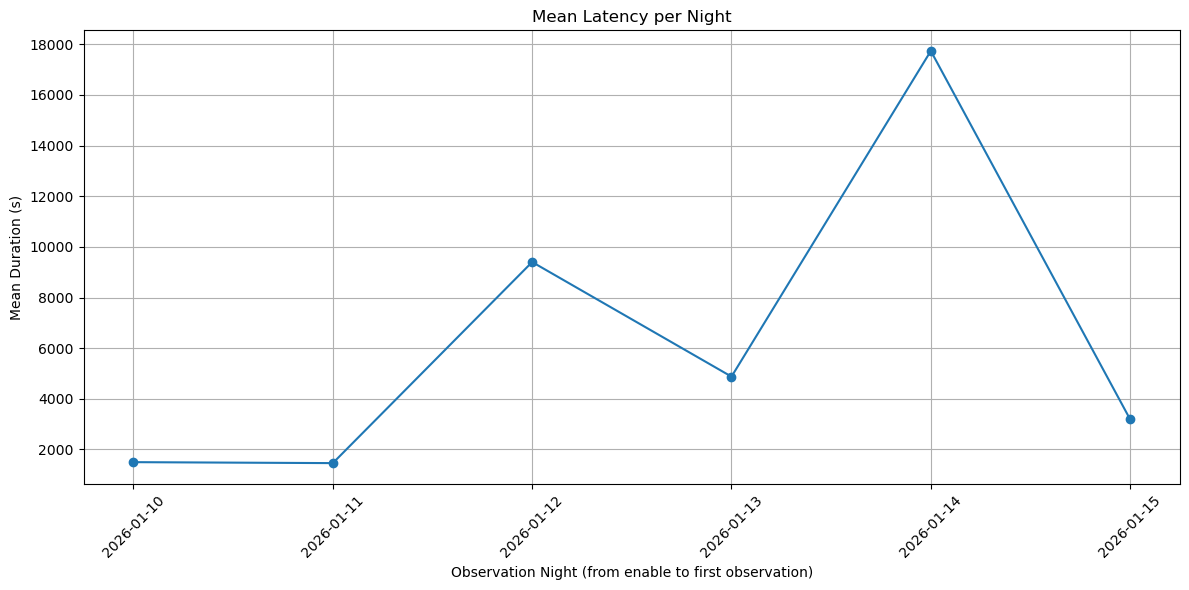

In [38]:
mean_by_night_cam['date'] = pd.to_datetime(mean_by_night_cam['date'])

plt.figure(figsize=(12,6))
plt.plot(mean_by_night_cam['date'], mean_by_night_cam['latency_camara'], marker='o')
plt.xlabel('Observation Night (from enable to first observation)')
plt.ylabel('Mean Duration (s)')
plt.title('Mean Latency per Night')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Change to minutes

In [39]:
mean_by_night_cam["latency_camara_min"] = (
    mean_by_night_cam["latency_camara"] / 60.0
)

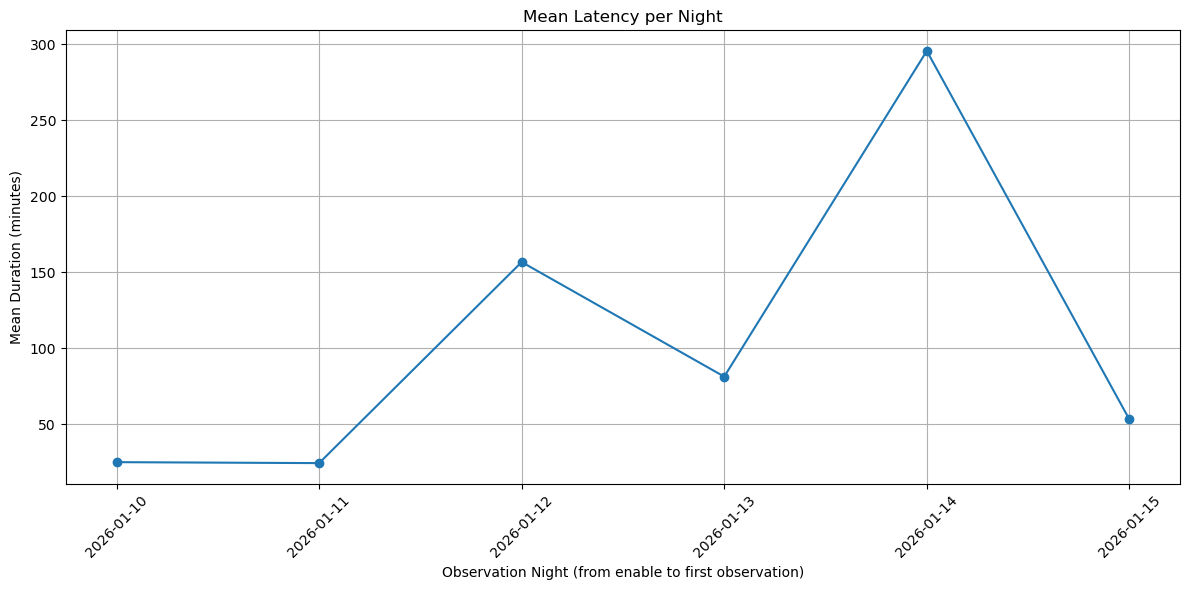

In [40]:
mean_by_night_cam["date"] = pd.to_datetime(mean_by_night_cam["date"])

plt.figure(figsize=(12, 6))
plt.plot(
    mean_by_night_cam["date"],
    mean_by_night_cam["latency_camara_min"],
    marker="o"
)

plt.xlabel("Observation Night (from enable to first observation)")
plt.ylabel("Mean Duration (minutes)")
plt.title("Mean Latency per Night")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()